### Setup

In [46]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [47]:
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

device

'cuda'

### Load Dataset

In [48]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

columns = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year", "origin", ]

df = pd.read_csv(url, names=columns, na_values="?", sep=r"\s+", usecols=range(8), )

df = df.dropna()

df = df.dropna()

print(df.shape)

df.head()

(392, 8)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


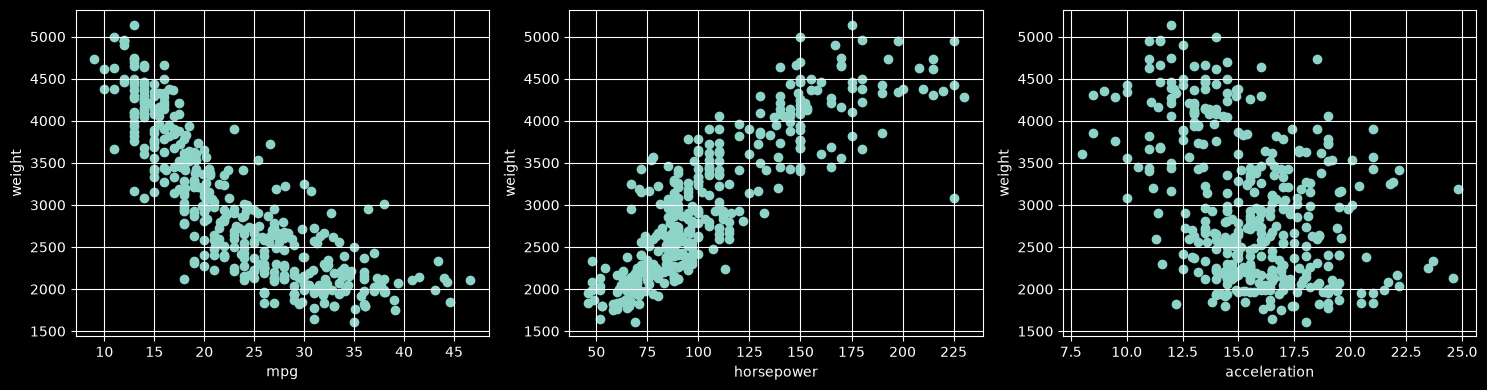

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feature in zip(axes.flat, ["mpg", "horsepower", "acceleration"]):
    ax.scatter(df[feature].values, df["weight"].values)
    ax.set_xlabel(feature)
    ax.set_ylabel("weight")
    ax.grid()

#axes.flat[-3].set_visible(False)
plt.tight_layout()
plt.show()

In [50]:
features = ["weight"]

targets = ["mpg", "horsepower", "acceleration"]

X = torch.tensor(df[features].values, dtype=torch.float32, device=device)

y = torch.tensor(df[targets].values, dtype=torch.float32, device=device)

In [51]:
X_mean = X.mean()
X_std = X.std()
X = (X-X_mean)/X_std

y_mean = y.mean()
y_std = y.std()
y = (y-y_mean)/y_std

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

(torch.Size([313, 1]),
 torch.Size([79, 1]),
 torch.Size([313, 3]),
 torch.Size([79, 3]))

### Model

In [53]:
class ModelNNN(nn.Module):
    def __init__(self, input_n, n, output_n):
        super().__init__()
        self.block = nn.Sequential(nn.Linear(input_n, n))
        self.output_layer = nn.Linear(n, output_n)

    def forward(self, X):
        block_output = self.block(X)
        return self.output_layer(block_output)

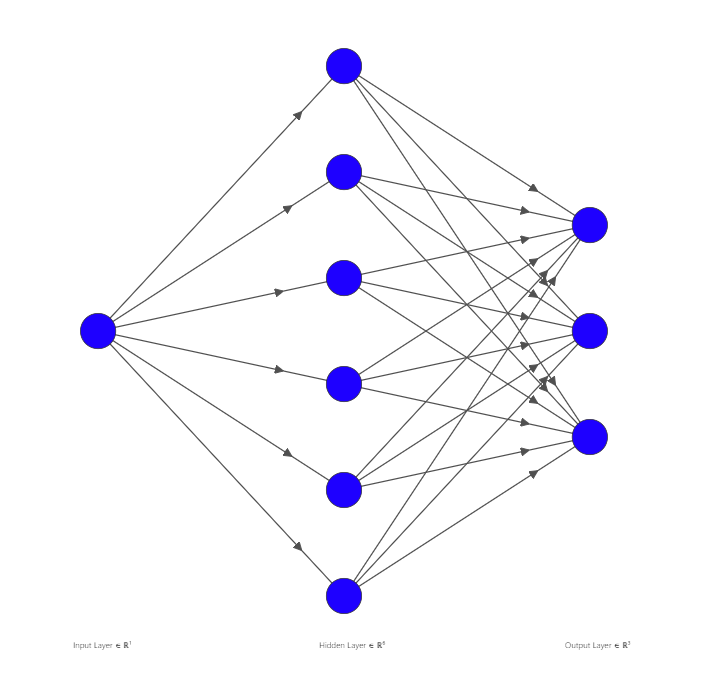
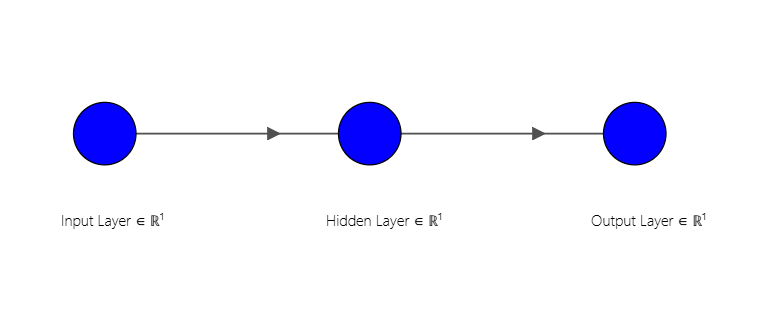
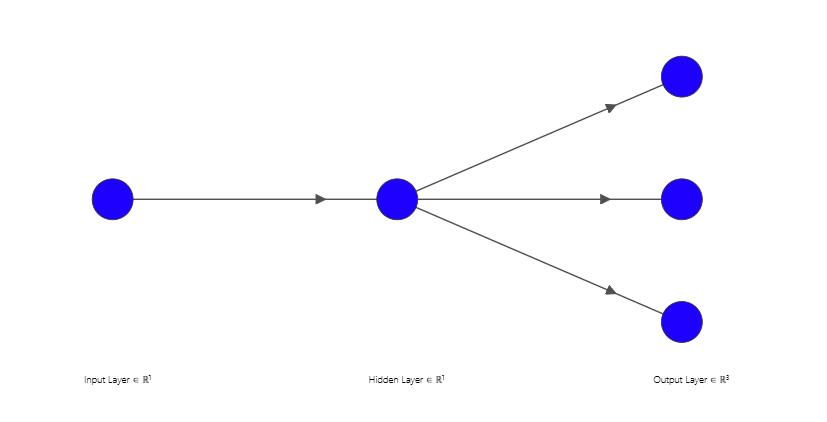
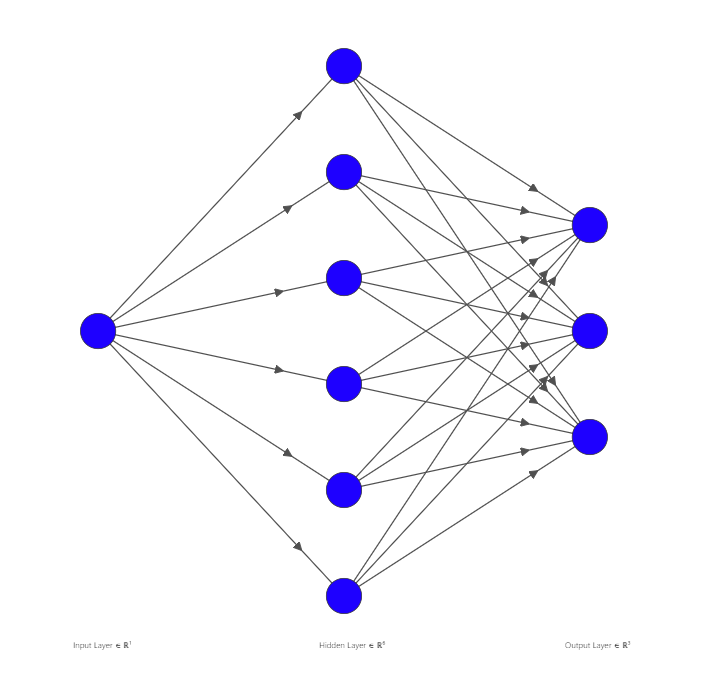

In [54]:
model = ModelNNN(1, 6, 3)
model = model.to(device)
model

ModelNNN(
  (block): Sequential(
    (0): Linear(in_features=1, out_features=6, bias=True)
  )
  (output_layer): Linear(in_features=6, out_features=3, bias=True)
)

### Training

In [55]:
def train(model, optimizer, criterion, X, y, n_epochs):
    losses = []
    for epoch in range(n_epochs):
        y_pred = model(X)
        loss = criterion(y_pred, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        losses.append(loss.item())
        print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {loss.item()}")
    return losses

In [56]:
learning_rate = 0.1
n_epochs = 30

optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
mse = nn.MSELoss()

In [57]:
loss = train(model, optimizer, mse, X_train, y_train, n_epochs)

Epoch 1/30, Loss: 1.4500452280044556
Epoch 2/30, Loss: 0.9222398996353149
Epoch 3/30, Loss: 0.5994998812675476
Epoch 4/30, Loss: 0.3958127200603485
Epoch 5/30, Loss: 0.26793304085731506
Epoch 6/30, Loss: 0.18930459022521973
Epoch 7/30, Loss: 0.14209868013858795
Epoch 8/30, Loss: 0.11428187042474747
Epoch 9/30, Loss: 0.0980183333158493
Epoch 10/30, Loss: 0.0884433165192604
Epoch 11/30, Loss: 0.08266932517290115
Epoch 12/30, Loss: 0.07904329150915146
Epoch 13/30, Loss: 0.07664258033037186
Epoch 14/30, Loss: 0.07495923340320587
Epoch 15/30, Loss: 0.07371395826339722
Epoch 16/30, Loss: 0.07275138050317764
Epoch 17/30, Loss: 0.07198262959718704
Epoch 18/30, Loss: 0.0713547095656395
Epoch 19/30, Loss: 0.0708342120051384
Epoch 20/30, Loss: 0.07039870321750641
Epoch 21/30, Loss: 0.07003221660852432
Epoch 22/30, Loss: 0.06972268223762512
Epoch 23/30, Loss: 0.06946070492267609
Epoch 24/30, Loss: 0.06923869252204895
Epoch 25/30, Loss: 0.06905040889978409
Epoch 26/30, Loss: 0.06889066100120544
Epo

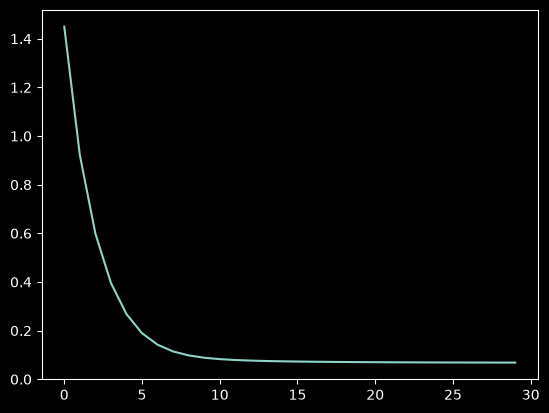

In [58]:
plt.plot(list(range(n_epochs)), loss)

### Evaluate

In [59]:
def evaluate(model, X, y, metric_fn, aggregate_fn=torch.mean):
    model.eval()
    metrics = []
    with torch.no_grad():
        for X_data, y_data in zip(X, y):
            y_pred = model(X_data)
            metric = metric_fn(y_pred, y_data)
            metrics.append(metric)
    return aggregate_fn(torch.stack(metrics))

In [60]:
evaluate(model, X_test, y_test, mse)

tensor(0.0400, device='cuda:0')

end